# Business Scenario

### You are acting as a Business Process Analyst / GRC Analyst / Operational Risk Analyst for a financial institution.

#### Leadership wants to understand:

- how loan applications move through the process
- where bottlenecks occur
- which steps create delays
- where rework or repeat activity happens
- whether controls are functioning effectively
- which applications create operational risk
- where process governance can be improved

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv(r"C:\Users\Amira\Downloads\Project4_loan_process\bpi_2017_cleaned.csv")

print(df.shape)
df.head()

(1202267, 19)


,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
#simplify column names

df = df.rename(columns={
    "case:concept:name": "case_id",
    "concept:name": "activity",
    "time:timestamp": "timestamp",
    "org:resource": "resource",
    "lifecycle:transition": "lifecycle",
    "case:LoanGoal": "loan_goal",
    "case:ApplicationType": "application_type",
    "case:RequestedAmount": "requested_amount"
})

df.head()

,Action,resource,activity,EventOrigin,EventID,lifecycle,timestamp,loan_goal,application_type,case_id,requested_amount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
#convert time
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)

#data review
print("Rows:", len(df))
print("Unique Cases:", df["case_id"].nunique())
print("Unique Activities:", df["activity"].nunique())
print("Unique Resources:", df["resource"].nunique())

df.info()

Rows: 1202267
Unique Cases: 31509
Unique Activities: 26
Unique Resources: 149
<class 'pandas.DataFrame'>
RangeIndex: 1202267 entries, 0 to 1202266
Data columns (total 19 columns):
 #   Column                 Non-Null Count    Dtype              
---  ------                 --------------    -----              
 0   Action                 1202267 non-null  str                
 1   resource               1202267 non-null  str                
 2   activity               1202267 non-null  str                
 3   EventOrigin            1202267 non-null  str                
 4   EventID                1202267 non-null  str                
 5   lifecycle              1202267 non-null  str                
 6   timestamp              1201090 non-null  datetime64[us, UTC]
 7   loan_goal              1202267 non-null  str                
 8   application_type       1202267 non-null  str                
 9   case_id                1202267 non-null  str                
 10  requested_amount       

In [4]:
#missing values
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_percent = (
    (missing / len(df)) * 100
).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percent": missing_percent
})

missing_df

,Missing Count,Missing Percent
CreditScore,1159272,96.42
OfferedAmount,1159272,96.42
MonthlyCost,1159272,96.42
NumberOfTerms,1159272,96.42
Accepted,1159272,96.42
FirstWithdrawalAmount,1159272,96.42
Selected,1159272,96.42
OfferID,1051413,87.45
timestamp,1177,0.10
Action,0,0.00


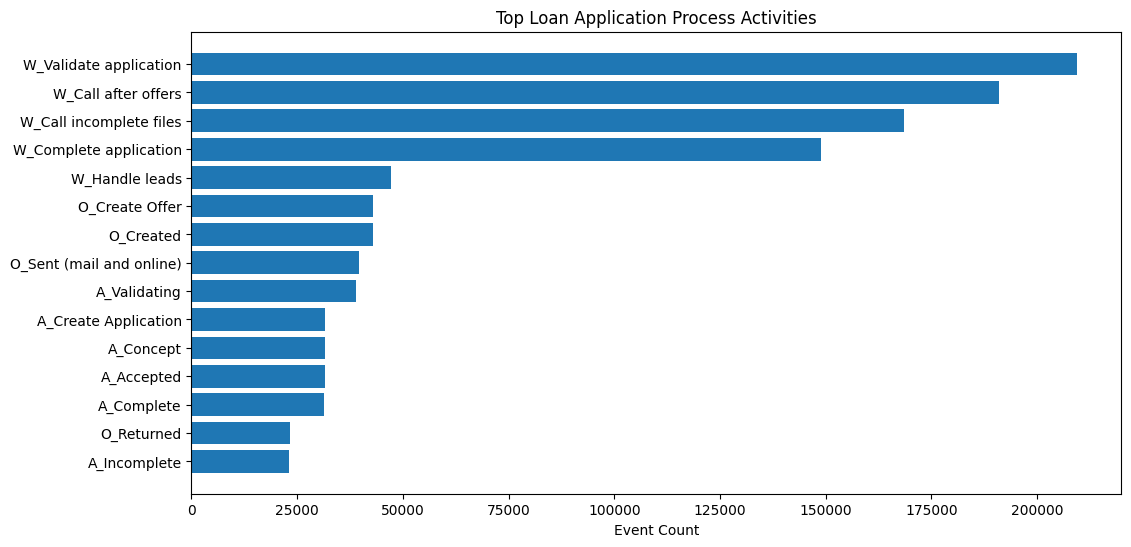

In [5]:
#top activities
activity_counts = (
    df["activity"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12, 6))

plt.barh(
    activity_counts.index,
    activity_counts.values
)

plt.title("Top Loan Application Process Activities")
plt.xlabel("Event Count")

plt.gca().invert_yaxis()

plt.show()

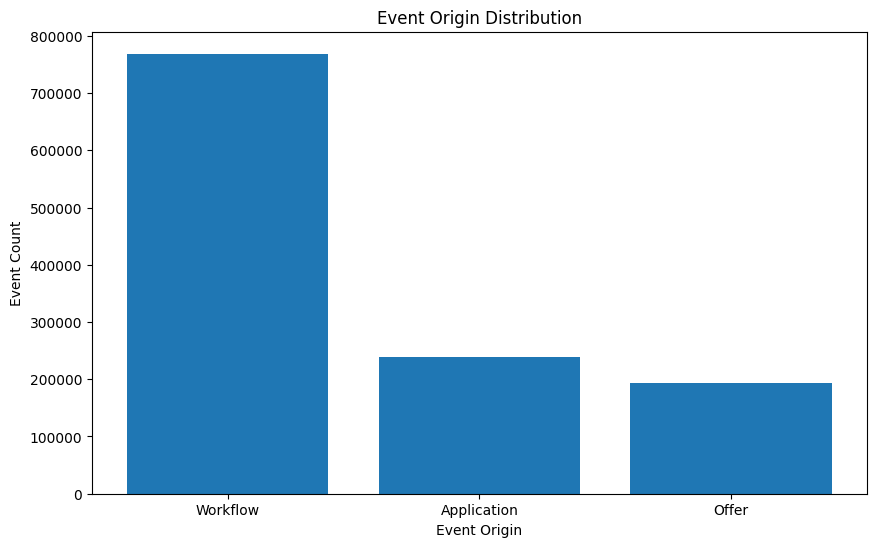

In [6]:
#origin dist
origin_counts = (
    df["EventOrigin"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    origin_counts.index,
    origin_counts.values
)

plt.title("Event Origin Distribution")
plt.xlabel("Event Origin")
plt.ylabel("Event Count")

plt.show()

In [7]:
##Case level process summary

#case summary
case_summary = (
    df.groupby("case_id")
      .agg(
          start_time=("timestamp", "min"),
          end_time=("timestamp", "max"),
          event_count=("activity", "count"),
          unique_activities=("activity", "nunique"),
          loan_goal=("loan_goal", "first"),
          application_type=("application_type", "first"),
          requested_amount=("requested_amount", "first"),
          accepted=("Accepted", "max"),
          credit_score=("CreditScore", "max"),
          offered_amount=("OfferedAmount", "max")
      )
      .reset_index()
)

case_summary["cycle_time_hours"] = (
    case_summary["end_time"] - case_summary["start_time"]
).dt.total_seconds() / 3600

case_summary.head()

,case_id,start_time,end_time,event_count,unique_activities,loan_goal,application_type,requested_amount,accepted,credit_score,offered_amount,cycle_time_hours
0,Application_1000086665,2016-08-03 15:57:21.673000+00:00,2016-09-05 06:00:36.893000+00:00,22,13,"Other, see explanation",New credit,5000.0,True,0.0,5000.0,782.054228
1,Application_1000158214,2016-06-02 10:14:26.844000+00:00,2016-06-10 11:02:01.282000+00:00,25,16,Home improvement,New credit,12500.0,True,929.0,12500.0,192.792899
2,Application_1000311556,2016-04-04 15:56:37.675000+00:00,2016-05-05 06:00:48.963000+00:00,18,11,Car,New credit,45000.0,True,0.0,45000.0,734.069802
3,Application_1000334415,2016-09-15 16:39:17.758000+00:00,2016-09-29 07:45:34.389000+00:00,40,18,"Other, see explanation",New credit,5000.0,True,0.0,5000.0,327.104620
4,Application_1000339879,2016-03-17 12:57:10.159000+00:00,2016-03-30 09:11:48.600000+00:00,51,18,Existing loan takeover,New credit,37500.0,True,798.0,37500.0,308.244011


In [8]:
#cycle time summary
case_summary["cycle_time_hours"].describe()

count    31509.000000
mean       525.590534
std        316.061581
min          0.055851
25%        271.792133
50%        458.105741
75%        755.897485
max       6865.738515
Name: cycle_time_hours, dtype: float64

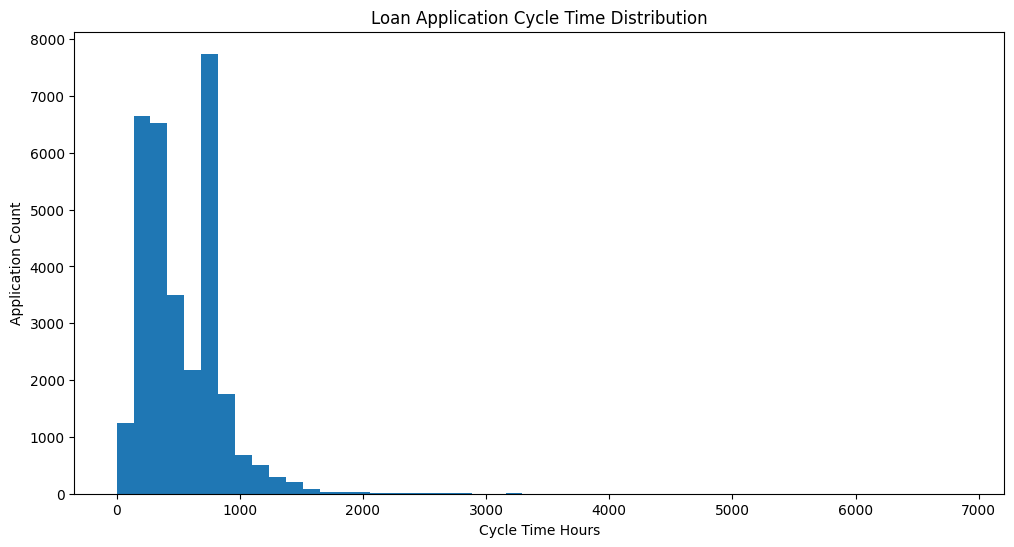

In [9]:
#cycle time dist
plt.figure(figsize=(12, 6))

plt.hist(
    case_summary["cycle_time_hours"].dropna(),
    bins=50
)

plt.title("Loan Application Cycle Time Distribution")
plt.xlabel("Cycle Time Hours")
plt.ylabel("Application Count")

plt.show()

In [11]:
##Bottleneck analysis

#average time between events
df = df.sort_values(["case_id", "timestamp"])

df["next_timestamp"] = (
    df.groupby("case_id")["timestamp"]
      .shift(-1)
)

df["next_activity"] = (
    df.groupby("case_id")["activity"]
      .shift(-1)
)

df["time_to_next_event_hours"] = (
    df["next_timestamp"] - df["timestamp"]
).dt.total_seconds() / 3600

df[[
    "case_id",
    "activity",
    "next_activity",
    "time_to_next_event_hours"
]].head()

,case_id,activity,next_activity,time_to_next_event_hours
686058,Application_1000086665,A_Create Application,A_Submitted,0.000017
686059,Application_1000086665,A_Submitted,W_Handle leads,0.000064
686060,Application_1000086665,W_Handle leads,W_Handle leads,0.018423
686061,Application_1000086665,W_Handle leads,W_Complete application,0.000002
686062,Application_1000086665,W_Complete application,A_Concept,0.000002


In [12]:
#bottleneck transitions
transition_times = (
    df.dropna(subset=["next_activity", "time_to_next_event_hours"])
      .groupby(["activity", "next_activity"])["time_to_next_event_hours"]
      .agg(["count", "mean", "median", "max"])
      .reset_index()
)

transition_times = transition_times.sort_values(
    "mean",
    ascending=False
)

transition_times.head(20)

,activity,next_activity,count,mean,median,max
156,W_Call incomplete files,W_Personal Loan collection,1,3201.613105,3201.613105,3201.613105
63,O_Cancelled,W_Shortened completion,1,2888.060861,2888.060861,2888.060861
99,O_Sent (mail and online),A_Cancelled,545,665.656798,736.197496,743.390985
111,O_Sent (online only),A_Cancelled,45,601.764260,736.439226,743.973941
129,W_Call after offers,A_Cancelled,8531,555.019137,640.920885,743.958550
175,W_Personal Loan collection,W_Personal Loan collection,19,455.435007,0.006986,3267.021072
197,W_Validate application,W_Personal Loan collection,2,241.997479,241.997479,483.986129
140,W_Call after offers,W_Shortened completion,26,166.583124,0.000001,2498.576134
145,W_Call incomplete files,A_Pending,4,157.781475,150.865126,327.605711
119,O_Sent (online only),W_Call after offers,298,140.074449,91.632686,716.887819


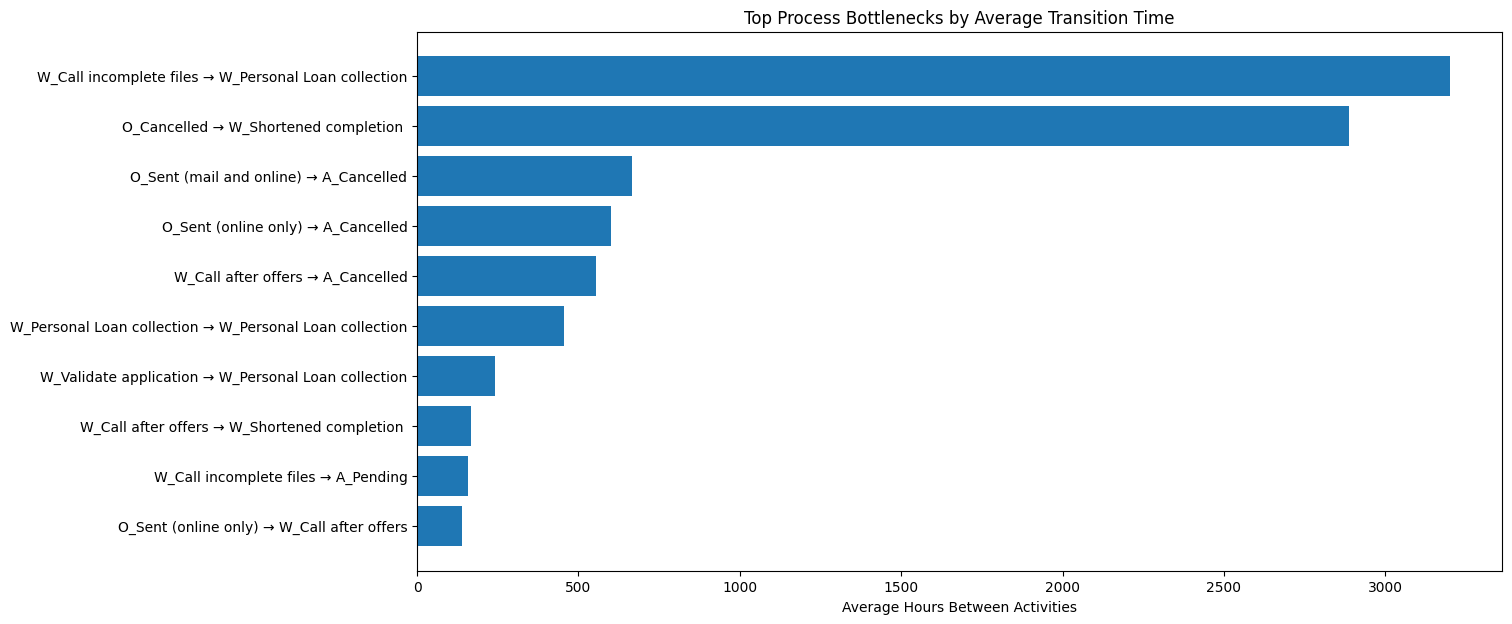

In [13]:
#bottleneck visual
top_bottlenecks = transition_times.head(10).copy()

top_bottlenecks["transition"] = (
    top_bottlenecks["activity"] + " → " + top_bottlenecks["next_activity"]
)

plt.figure(figsize=(14, 7))

plt.barh(
    top_bottlenecks["transition"],
    top_bottlenecks["mean"]
)

plt.title("Top Process Bottlenecks by Average Transition Time")
plt.xlabel("Average Hours Between Activities")

plt.gca().invert_yaxis()

plt.show()

In [14]:
##Process governance flags

#sla flag
sla_threshold = case_summary["cycle_time_hours"].quantile(0.90)

case_summary["sla_breach_flag"] = (
    case_summary["cycle_time_hours"] > sla_threshold
)

print("SLA Threshold Hours:", round(sla_threshold, 2))
print("SLA Breach Cases:", case_summary["sla_breach_flag"].sum())

SLA Threshold Hours: 841.32
SLA Breach Cases: 3151


In [15]:
#excessive rework flags
rework_threshold = case_summary["event_count"].quantile(0.90)

case_summary["excessive_rework_flag"] = (
    case_summary["event_count"] > rework_threshold
)

print("Rework Threshold Event Count:", rework_threshold)
print("Excessive Rework Cases:", case_summary["excessive_rework_flag"].sum())

Rework Threshold Event Count: 60.0
Excessive Rework Cases: 3049


In [16]:
#missing credit score flag
case_summary["missing_credit_score_flag"] = (
    case_summary["credit_score"].isna()
)

case_summary["missing_credit_score_flag"].sum()

np.int64(0)

In [17]:
#missing offer amount flag
case_summary["missing_offered_amount_flag"] = (
    case_summary["offered_amount"].isna()
)

case_summary["missing_offered_amount_flag"].sum()

np.int64(0)

In [18]:
##Process risk scoring
case_summary["process_risk_score"] = 0

case_summary.loc[
    case_summary["sla_breach_flag"],
    "process_risk_score"
] += 3

case_summary.loc[
    case_summary["excessive_rework_flag"],
    "process_risk_score"
] += 2

case_summary.loc[
    case_summary["missing_credit_score_flag"],
    "process_risk_score"
] += 2

case_summary.loc[
    case_summary["missing_offered_amount_flag"],
    "process_risk_score"
] += 2

case_summary.loc[
    case_summary["requested_amount"] >= case_summary["requested_amount"].quantile(0.90),
    "process_risk_score"
] += 2

In [19]:
##process risk level
def process_risk_level(score):

    if score <= 2:
        return "Low"

    elif score <= 5:
        return "Medium"

    elif score <= 8:
        return "High"

    else:
        return "Critical"

case_summary["process_risk_level"] = (
    case_summary["process_risk_score"]
    .apply(process_risk_level)
)

case_summary[[
    "case_id",
    "cycle_time_hours",
    "event_count",
    "process_risk_score",
    "process_risk_level"
]].head()

,case_id,cycle_time_hours,event_count,process_risk_score,process_risk_level
0,Application_1000086665,782.054228,22,0,Low
1,Application_1000158214,192.792899,25,0,Low
2,Application_1000311556,734.069802,18,2,Low
3,Application_1000334415,327.104620,40,0,Low
4,Application_1000339879,308.244011,51,2,Low


In [20]:
##Control testing

#process control rules
case_summary["ctrl_case_has_start_end"] = (
    case_summary["start_time"].notna() &
    case_summary["end_time"].notna()
)

case_summary["ctrl_requested_amount_present"] = (
    case_summary["requested_amount"].notna()
)

case_summary["ctrl_credit_score_present"] = (
    case_summary["credit_score"].notna()
)

case_summary["ctrl_offered_amount_present"] = (
    case_summary["offered_amount"].notna()
)

case_summary["ctrl_cycle_time_within_sla"] = (
    ~case_summary["sla_breach_flag"]
)

case_summary["ctrl_rework_within_threshold"] = (
    ~case_summary["excessive_rework_flag"]
)

#auto control testing summary
control_tests = {
    "CTRL-001 Case Start and End Present": "ctrl_case_has_start_end",
    "CTRL-002 Requested Amount Present": "ctrl_requested_amount_present",
    "CTRL-003 Credit Score Present": "ctrl_credit_score_present",
    "CTRL-004 Offered Amount Present": "ctrl_offered_amount_present",
    "CTRL-005 Cycle Time Within SLA": "ctrl_cycle_time_within_sla",
    "CTRL-006 Rework Within Threshold": "ctrl_rework_within_threshold"
}

control_results = []

for control_name, rule_col in control_tests.items():

    total_tested = len(case_summary)
    passed = int(case_summary[rule_col].sum())
    failed = total_tested - passed
    pass_rate = round((passed / total_tested) * 100, 2)

    if pass_rate >= 95:
        effectiveness = "Effective"
    elif pass_rate >= 85:
        effectiveness = "Needs Monitoring"
    else:
        effectiveness = "Ineffective"

    control_results.append({
        "Control": control_name,
        "Total Tested": total_tested,
        "Passed": passed,
        "Failed": failed,
        "Pass Rate %": pass_rate,
        "Effectiveness": effectiveness
    })

control_summary_df = pd.DataFrame(control_results)

control_summary_df

,Control,Total Tested,Passed,Failed,Pass Rate %,Effectiveness
0,CTRL-001 Case Start and End Present,31509,31509,0,100.00,Effective
1,CTRL-002 Requested Amount Present,31509,31509,0,100.00,Effective
2,CTRL-003 Credit Score Present,31509,31509,0,100.00,Effective
3,CTRL-004 Offered Amount Present,31509,31509,0,100.00,Effective
4,CTRL-005 Cycle Time Within SLA,31509,28358,3151,90.00,Needs Monitoring
5,CTRL-006 Rework Within Threshold,31509,28460,3049,90.32,Needs Monitoring


In [21]:
##======KPIs======##

total_cases = len(case_summary)

avg_cycle_time = round(
    case_summary["cycle_time_hours"].mean(),
    2
)

sla_breaches = int(
    case_summary["sla_breach_flag"].sum()
)

rework_cases = int(
    case_summary["excessive_rework_flag"].sum()
)

high_risk_cases = len(
    case_summary[case_summary["process_risk_level"] == "High"]
)

critical_risk_cases = len(
    case_summary[case_summary["process_risk_level"] == "Critical"]
)

print("Total Cases:", total_cases)
print("Average Cycle Time Hours:", avg_cycle_time)
print("SLA Breaches:", sla_breaches)
print("Excessive Rework Cases:", rework_cases)
print("High Risk Cases:", high_risk_cases)
print("Critical Risk Cases:", critical_risk_cases)

Total Cases: 31509
Average Cycle Time Hours: 525.59
SLA Breaches: 3151
Excessive Rework Cases: 3049
High Risk Cases: 161
Critical Risk Cases: 0


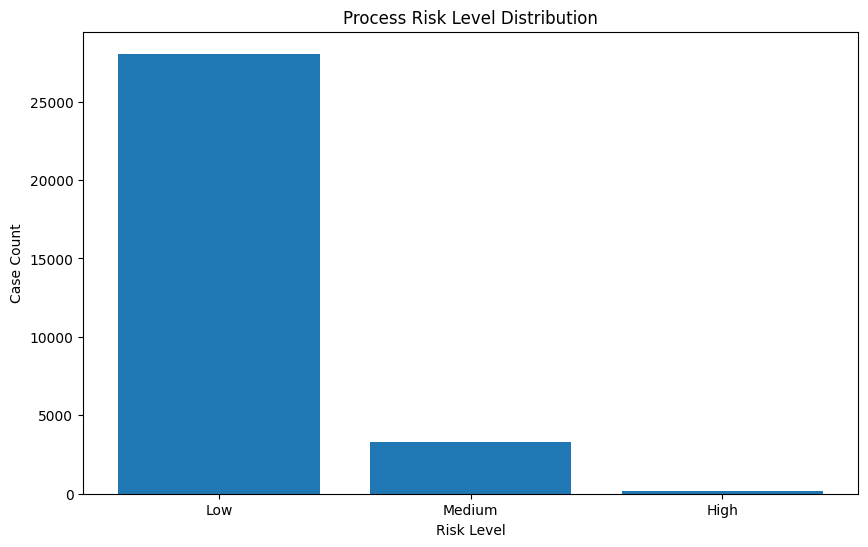

In [22]:
##Process risk dist
risk_counts = (
    case_summary["process_risk_level"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.title("Process Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Case Count")

plt.show()

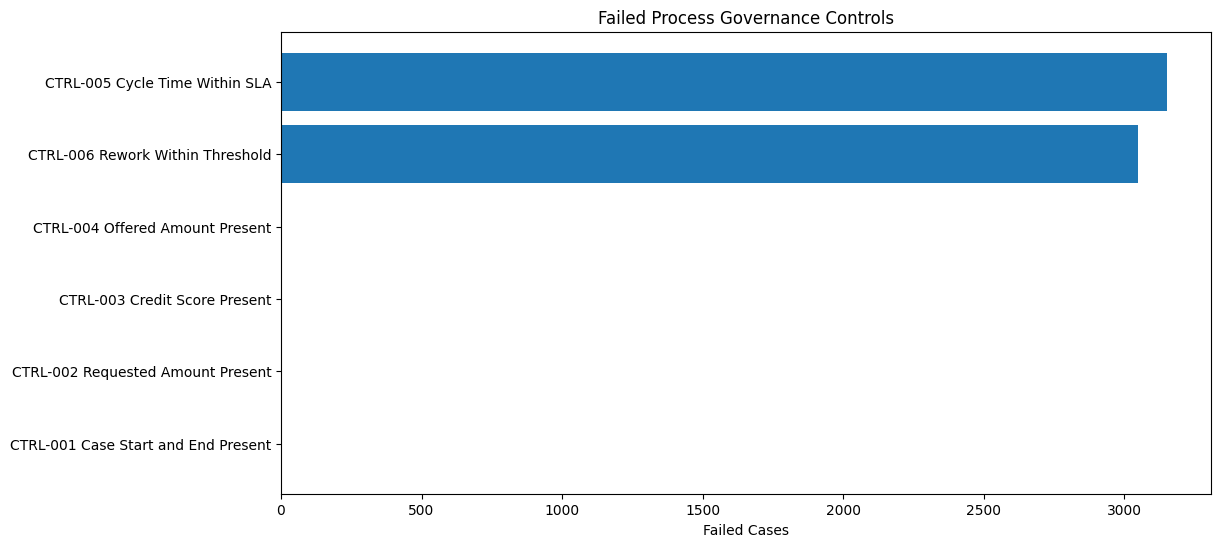

In [23]:
#failed control counts
failed_control_chart = (
    control_summary_df
    .sort_values("Failed", ascending=True)
)

plt.figure(figsize=(12, 6))

plt.barh(
    failed_control_chart["Control"],
    failed_control_chart["Failed"]
)

plt.title("Failed Process Governance Controls")
plt.xlabel("Failed Cases")

plt.show()

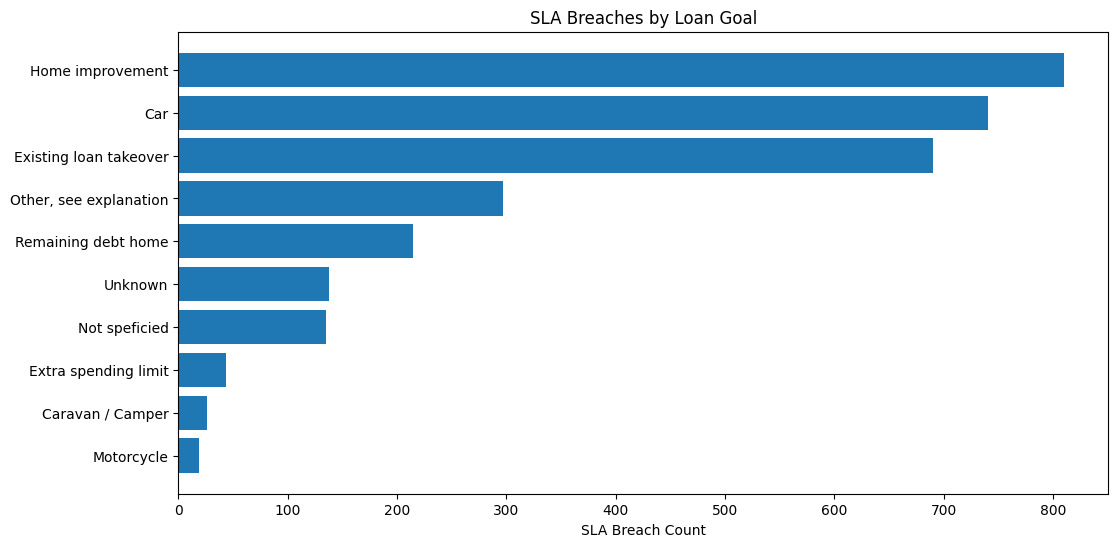

In [24]:
#sla breach by goal
sla_by_goal = (
    case_summary
    .groupby("loan_goal")["sla_breach_flag"]
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

plt.figure(figsize=(12, 6))

plt.barh(
    sla_by_goal.index,
    sla_by_goal.values
)

plt.title("SLA Breaches by Loan Goal")
plt.xlabel("SLA Breach Count")

plt.show()

## Loan Application Process Governance Framework

This project evaluates a loan application event-log dataset from a business process governance and operational risk perspective.

The analysis transforms raw process event data into a case-level governance framework by calculating cycle time, event counts, rework indicators, SLA breaches, and missing control fields.

Each loan application case is evaluated using process governance controls, including start/end timestamp availability, requested amount completeness, credit score availability, offered amount availability, SLA compliance, and rework thresholds.

The purpose of this framework is to identify bottlenecks, process inefficiencies, control gaps, and high-risk applications requiring operational review or process improvement.

---

In [25]:
##Process flow map and transition matrix

#trans counts
transition_counts = (
    df.dropna(subset=["activity", "next_activity"])
      .groupby(["activity", "next_activity"])
      .size()
      .reset_index(name="transition_count")
      .sort_values("transition_count", ascending=False)
)

transition_counts.head(20)

,activity,next_activity,transition_count
242,W_Validate application,W_Validate application,115515
157,W_Call after offers,W_Call after offers,115461
182,W_Call incomplete files,W_Call incomplete files,113836
199,W_Complete application,W_Complete application,64625
78,O_Create Offer,O_Created,42914
226,W_Validate application,A_Validating,38800
87,O_Created,O_Sent (mail and online),35544
144,W_Call after offers,A_Complete,31349
197,W_Complete application,W_Call after offers,31337
121,O_Sent (mail and online),W_Complete application,30856


In [26]:
#trans matrix
transition_matrix = pd.crosstab(
    df["activity"],
    df["next_activity"]
)

transition_matrix.head()

#save
from pathlib import Path

Path("outputs/tables").mkdir(
    parents=True,
    exist_ok=True
)

transition_matrix.to_csv(
    "outputs/tables/process_transition_matrix.csv"
)

print("Process transition matrix saved successfully.")

Process transition matrix saved successfully.


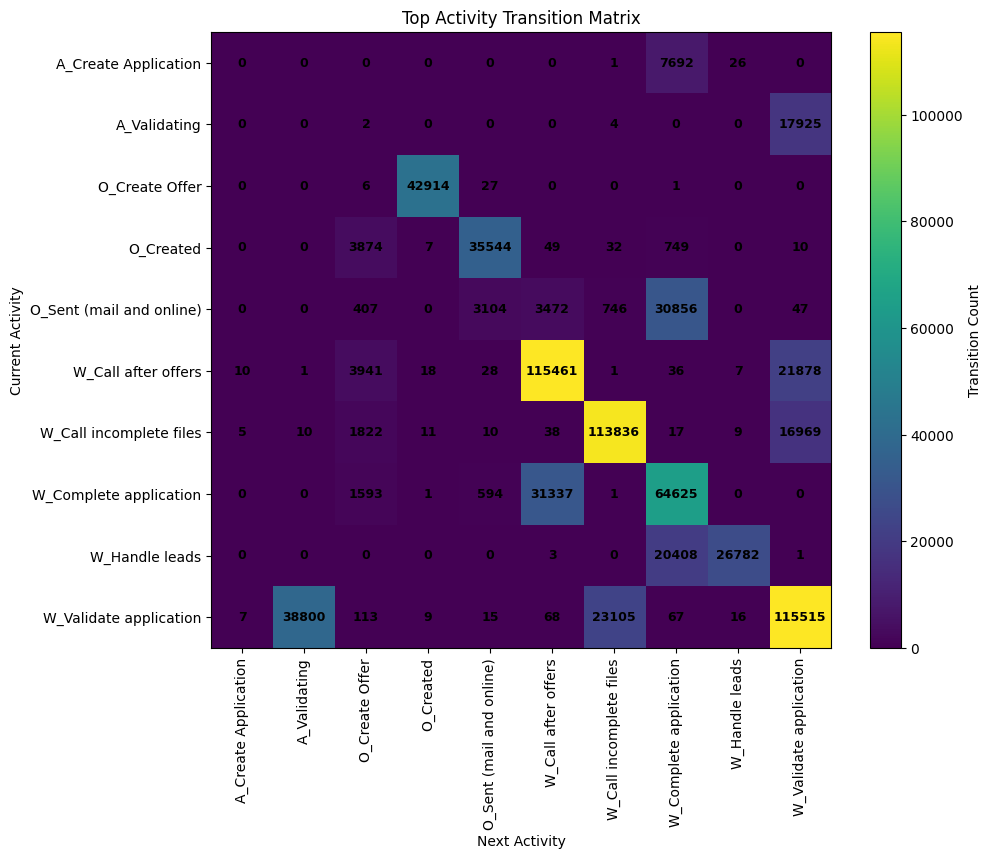

In [28]:
#trans heatmap

#top activities
top_activities = (
    df["activity"]
    .value_counts()
    .head(10)
    .index
)

transition_matrix_top = transition_matrix.loc[
    transition_matrix.index.intersection(top_activities),
    transition_matrix.columns.intersection(top_activities)
]

transition_matrix_top

#plot
plt.figure(figsize=(10, 8))

plt.imshow(
    transition_matrix_top,
    aspect="auto"
)

plt.colorbar(label="Transition Count")

for i in range(transition_matrix_top.shape[0]):
    for j in range(transition_matrix_top.shape[1]):
        plt.text(
            j,
            i,
            int(transition_matrix_top.iloc[i, j]),
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold"
        )

plt.xticks(
    range(len(transition_matrix_top.columns)),
    transition_matrix_top.columns,
    rotation=90
)

plt.yticks(
    range(len(transition_matrix_top.index)),
    transition_matrix_top.index
)

plt.title("Top Activity Transition Matrix")
plt.xlabel("Next Activity")
plt.ylabel("Current Activity")

plt.show()

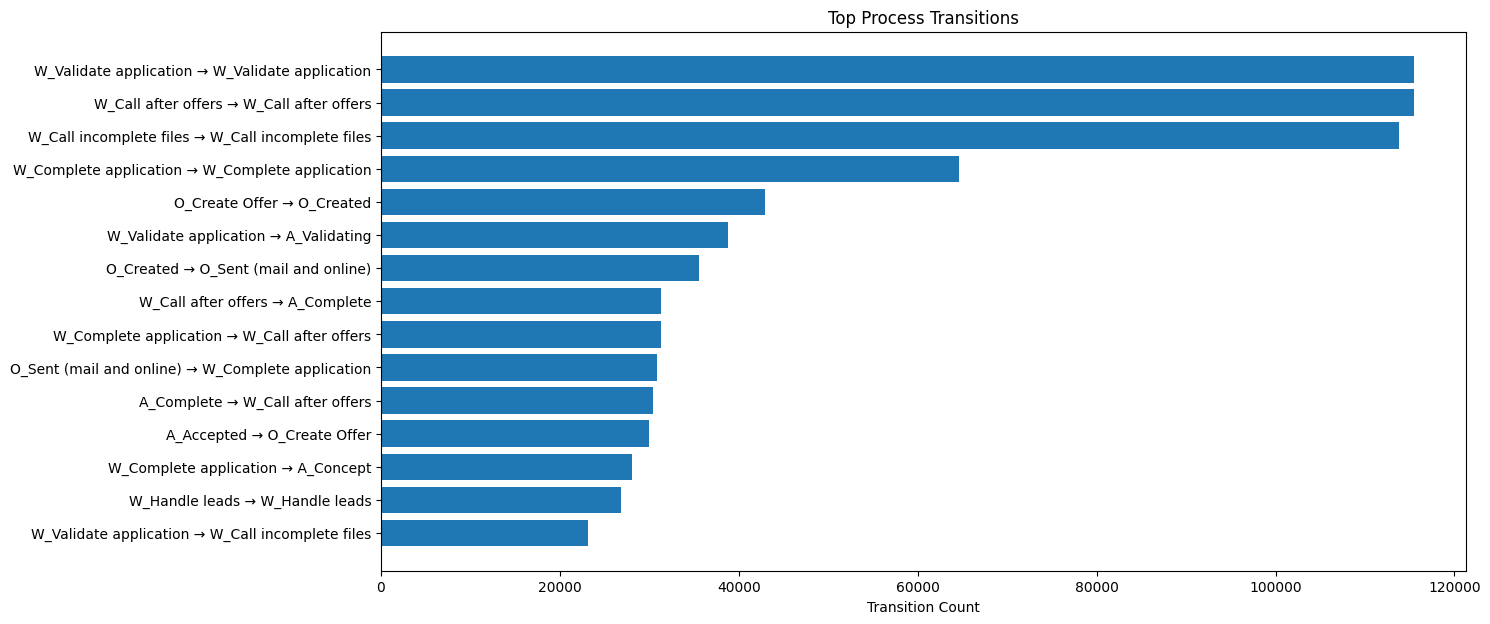

In [29]:
#Top process flow table
top_transitions = transition_counts.head(15).copy()

top_transitions["transition"] = (
    top_transitions["activity"] + " → " + top_transitions["next_activity"]
)

top_transitions[[
    "transition",
    "transition_count"
]]

#visual
plt.figure(figsize=(14, 7))

plt.barh(
    top_transitions["transition"],
    top_transitions["transition_count"]
)

plt.title("Top Process Transitions")
plt.xlabel("Transition Count")

plt.gca().invert_yaxis()

plt.show()

In [30]:
##Process flow map using NetworkX

%pip install networkx
import networkx as nx


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Amira\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----------------------------------- ---- 1.8/2.1 MB 15.1 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 10.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [31]:
#process flow edges

flow_edges = transition_counts.head(20).copy()

flow_edges.head()

,activity,next_activity,transition_count
242,W_Validate application,W_Validate application,115515
157,W_Call after offers,W_Call after offers,115461
182,W_Call incomplete files,W_Call incomplete files,113836
199,W_Complete application,W_Complete application,64625
78,O_Create Offer,O_Created,42914


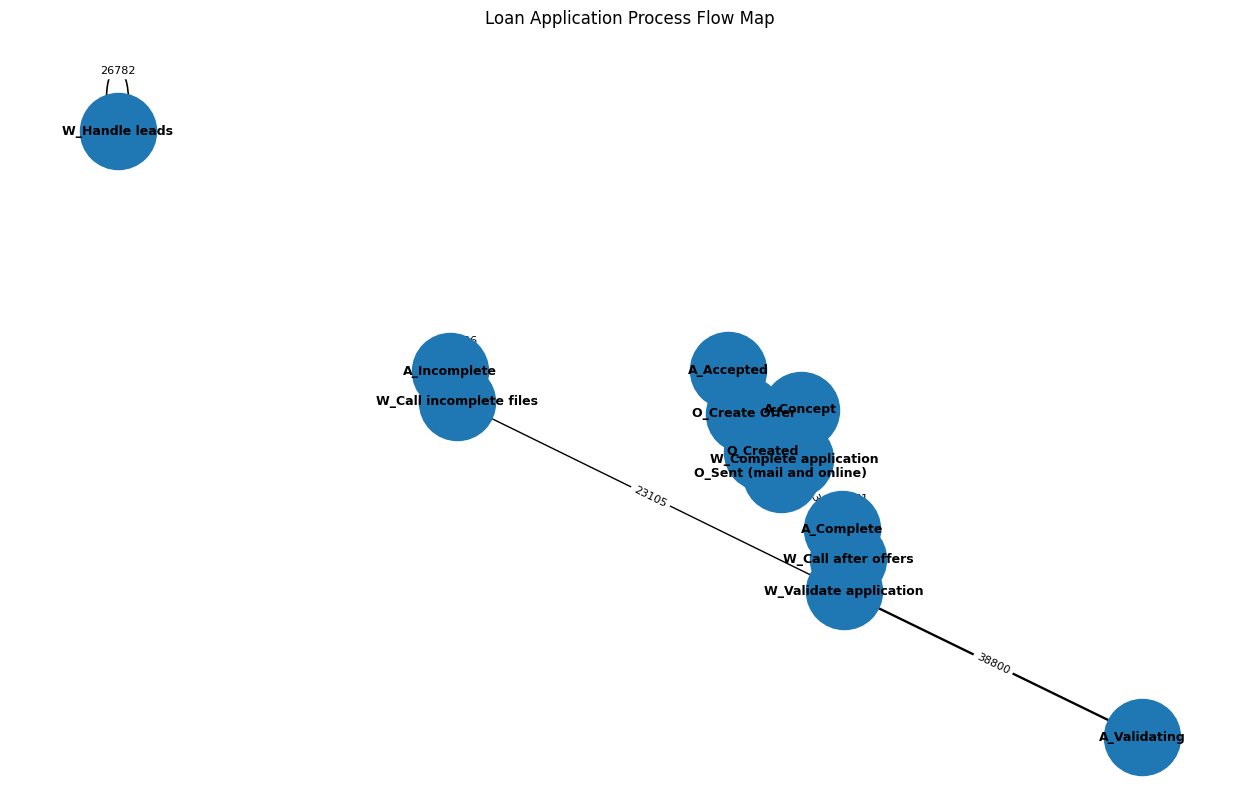

In [35]:
#build graph
G = nx.DiGraph()

for _, row in flow_edges.iterrows():
    G.add_edge(
        row["activity"],
        row["next_activity"],
        weight=row["transition_count"]
    )

#draw map
plt.figure(figsize=(16, 10))

pos = nx.spring_layout(G, seed=42, k=2)

edge_weights = [G[u][v]["weight"] for u, v in G.edges()]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=3000
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=9,
    font_weight="bold"
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    width=[w / max(edge_weights) * 5 for w in edge_weights]
)

edge_labels = {
    (u, v): G[u][v]["weight"]
    for u, v in G.edges()
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("Loan Application Process Flow Map")
plt.axis("off")

#save
plt.savefig(
    "outputs/charts/process_flow_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [36]:
#Rework/repeat analysis

#repeat within cases
activity_rework = (
    df.groupby(["case_id", "activity"])
      .size()
      .reset_index(name="activity_count")
)

rework_activities = (
    activity_rework[activity_rework["activity_count"] > 1]
    .groupby("activity")["activity_count"]
    .count()
    .sort_values(ascending=False)
)

rework_activities.head(15)

activity
W_Complete application      31509
W_Call after offers         31362
W_Validate application      21870
W_Handle leads              20423
W_Call incomplete files     15003
A_Validating                11669
O_Created                    8559
O_Create Offer               8559
O_Sent (mail and online)     6834
A_Incomplete                 5686
O_Cancelled                  3867
O_Returned                   1493
O_Refused                     777
W_Assess potential fraud      303
O_Sent (online only)          171
Name: activity_count, dtype: int64

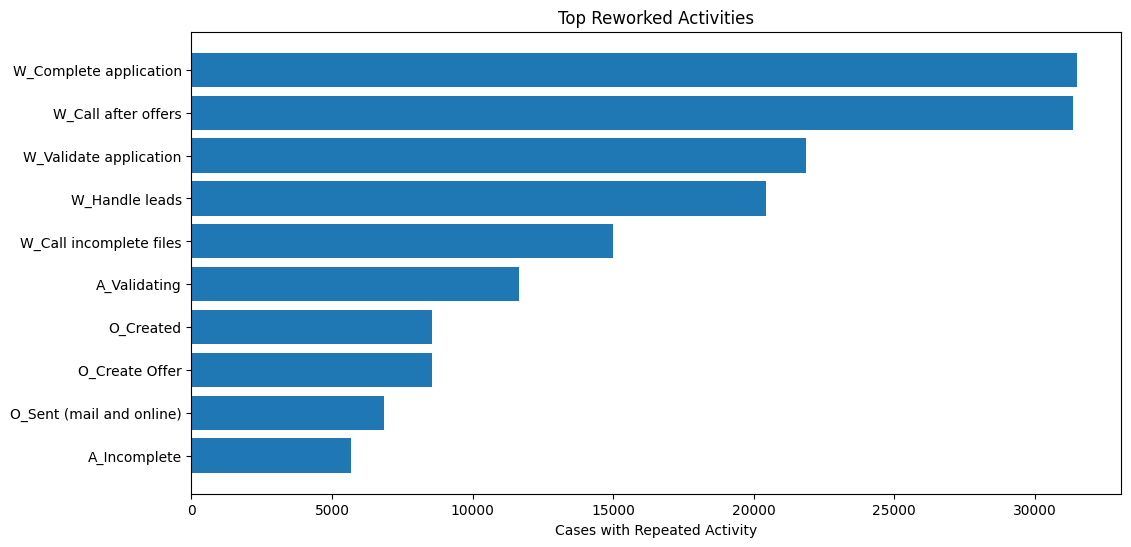

In [37]:
#visual
top_rework = rework_activities.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top_rework.index,
    top_rework.values
)

plt.title("Top Reworked Activities")
plt.xlabel("Cases with Repeated Activity")

plt.gca().invert_yaxis()

plt.show()

## Process Flow Map and Transition Matrix

A transition matrix and process flow map were created to visualize how loan applications move between activities in the process.

The transition matrix summarizes the frequency of activity-to-activity movement, allowing identification of the most common process paths and transition concentrations. This helps reveal where work typically flows and where complexity may exist.

The process flow map provides a network-style visualization of the most common transitions between activities. Nodes represent process activities and arrows represent movement between steps. Edge thickness and labels reflect transition volume.

Together, these views support:
- business process mapping
- workflow transparency
- bottleneck identification
- operational control analysis
- rework detection
- process governance monitoring

A rework analysis was also performed to identify activities that occur repeatedly within the same case. Repeated activities may indicate inefficient workflows, control breakdowns, incomplete documentation, or manual rework.

---

In [38]:
##Case status/outcome register

#final activity per case
final_activity = (
    df.sort_values(["case_id", "timestamp"])
      .groupby("case_id")
      .tail(1)[["case_id", "activity", "timestamp"]]
      .rename(columns={
          "activity": "final_activity",
          "timestamp": "final_timestamp"
      })
)

case_summary = case_summary.merge(
    final_activity,
    on="case_id",
    how="left"
)

case_summary[[
    "case_id",
    "final_activity",
    "final_timestamp"
]].head()

,case_id,final_activity,final_timestamp
0,Application_1000086665,W_Call after offers,2016-09-05 06:00:36.893000+00:00
1,Application_1000158214,W_Validate application,2016-06-10 11:02:01.282000+00:00
2,Application_1000311556,W_Call after offers,2016-05-05 06:00:48.963000+00:00
3,Application_1000334415,W_Validate application,2016-09-29 07:45:34.389000+00:00
4,Application_1000339879,W_Validate application,2016-03-30 09:11:48.600000+00:00


In [39]:
#outcome classification
def classify_case_outcome(row):

    final_activity = str(row["final_activity"]).lower()

    if row["accepted"] == 1:
        return "Accepted"

    elif "refused" in final_activity:
        return "Rejected"

    elif "cancel" in final_activity:
        return "Cancelled"

    elif "withdraw" in final_activity:
        return "Withdrawn"

    elif "denied" in final_activity:
        return "Rejected"

    else:
        return "Unresolved / Other"


case_summary["case_outcome"] = (
    case_summary.apply(classify_case_outcome, axis=1)
)

case_summary["case_outcome"].value_counts()

case_outcome
Accepted              23014
Unresolved / Other     7667
Cancelled               825
Rejected                  3
Name: count, dtype: int64

In [40]:
#case status
def assign_case_status(row):

    if row["process_risk_level"] == "Critical":
        return "Escalated"

    elif row["sla_breach_flag"] == True:
        return "SLA Breach Review"

    elif row["excessive_rework_flag"] == True:
        return "Rework Review"

    elif row["missing_credit_score_flag"] == True:
        return "Documentation Review"

    elif row["missing_offered_amount_flag"] == True:
        return "Offer Data Review"

    elif row["case_outcome"] == "Unresolved / Other":
        return "Outcome Review"

    else:
        return "Closed / Normal"


case_summary["case_status"] = (
    case_summary.apply(assign_case_status, axis=1)
)

case_summary["case_status"].value_counts()

case_status
Closed / Normal      19714
Outcome Review        6496
SLA Breach Review     3151
Rework Review         2148
Name: count, dtype: int64

In [41]:
#risk owner assignment
def assign_case_owner(row):

    if row["case_status"] == "Escalated":
        return "Operational Risk Team"

    elif row["case_status"] == "SLA Breach Review":
        return "Loan Operations Management"

    elif row["case_status"] == "Rework Review":
        return "Process Improvement Team"

    elif row["case_status"] in [
        "Documentation Review",
        "Offer Data Review"
    ]:
        return "Loan Quality Assurance"

    elif row["case_status"] == "Outcome Review":
        return "Application Processing Team"

    else:
        return "Standard Loan Operations"


case_summary["case_owner"] = (
    case_summary.apply(assign_case_owner, axis=1)
)

case_summary["case_owner"].value_counts()

case_owner
Standard Loan Operations       19714
Application Processing Team     6496
Loan Operations Management      3151
Process Improvement Team        2148
Name: count, dtype: int64

In [42]:
#recommended governance action
def recommended_case_action(row):

    if row["process_risk_level"] == "Critical":
        return "Escalate to operational risk leadership for immediate review"

    elif row["sla_breach_flag"] == True:
        return "Review process delay drivers and update SLA monitoring controls"

    elif row["excessive_rework_flag"] == True:
        return "Analyze repeated activity pattern and identify rework root cause"

    elif row["missing_credit_score_flag"] == True:
        return "Validate credit decision documentation and update missing credit score"

    elif row["missing_offered_amount_flag"] == True:
        return "Review offer record completeness and correct missing offered amount"

    elif row["case_outcome"] == "Unresolved / Other":
        return "Review final case activity and confirm application outcome"

    else:
        return "No action required beyond standard monitoring"


case_summary["recommended_action"] = (
    case_summary.apply(recommended_case_action, axis=1)
)

In [43]:
#build register
case_status_register = case_summary[[
    "case_id",
    "loan_goal",
    "application_type",
    "requested_amount",
    "accepted",
    "case_outcome",
    "final_activity",
    "cycle_time_hours",
    "event_count",
    "unique_activities",
    "sla_breach_flag",
    "excessive_rework_flag",
    "missing_credit_score_flag",
    "missing_offered_amount_flag",
    "process_risk_score",
    "process_risk_level",
    "case_status",
    "case_owner",
    "recommended_action"
]].copy()

case_status_register.head()

,case_id,loan_goal,application_type,requested_amount,accepted,case_outcome,final_activity,cycle_time_hours,event_count,unique_activities,sla_breach_flag,excessive_rework_flag,missing_credit_score_flag,missing_offered_amount_flag,process_risk_score,process_risk_level,case_status,case_owner,recommended_action
0,Application_1000086665,"Other, see explanation",New credit,5000.0,True,Accepted,W_Call after offers,782.054228,22,13,False,False,False,False,0,Low,Closed / Normal,Standard Loan Operations,No action required beyond standard monitoring
1,Application_1000158214,Home improvement,New credit,12500.0,True,Accepted,W_Validate application,192.792899,25,16,False,False,False,False,0,Low,Closed / Normal,Standard Loan Operations,No action required beyond standard monitoring
2,Application_1000311556,Car,New credit,45000.0,True,Accepted,W_Call after offers,734.069802,18,11,False,False,False,False,2,Low,Closed / Normal,Standard Loan Operations,No action required beyond standard monitoring
3,Application_1000334415,"Other, see explanation",New credit,5000.0,True,Accepted,W_Validate application,327.104620,40,18,False,False,False,False,0,Low,Closed / Normal,Standard Loan Operations,No action required beyond standard monitoring
4,Application_1000339879,Existing loan takeover,New credit,37500.0,True,Accepted,W_Validate application,308.244011,51,18,False,False,False,False,2,Low,Closed / Normal,Standard Loan Operations,No action required beyond standard monitoring


In [44]:
#save
from pathlib import Path

Path("outputs/tables").mkdir(
    parents=True,
    exist_ok=True
)

case_status_register.to_csv(
    "outputs/tables/case_status_outcome_register.csv",
    index=False
)

print("Case status/outcome register saved successfully.")

Case status/outcome register saved successfully.


In [45]:
##Case outcome KPIs

total_cases = len(case_status_register)

accepted_cases = len(
    case_status_register[
        case_status_register["case_outcome"] == "Accepted"
    ]
)

unresolved_cases = len(
    case_status_register[
        case_status_register["case_outcome"] == "Unresolved / Other"
    ]
)

escalated_cases = len(
    case_status_register[
        case_status_register["case_status"] == "Escalated"
    ]
)

sla_review_cases = len(
    case_status_register[
        case_status_register["case_status"] == "SLA Breach Review"
    ]
)

rework_review_cases = len(
    case_status_register[
        case_status_register["case_status"] == "Rework Review"
    ]
)

print("Total Cases:", total_cases)
print("Accepted Cases:", accepted_cases)
print("Unresolved Cases:", unresolved_cases)
print("Escalated Cases:", escalated_cases)
print("SLA Review Cases:", sla_review_cases)
print("Rework Review Cases:", rework_review_cases)

Total Cases: 31509
Accepted Cases: 23014
Unresolved Cases: 7667
Escalated Cases: 0
SLA Review Cases: 3151
Rework Review Cases: 2148


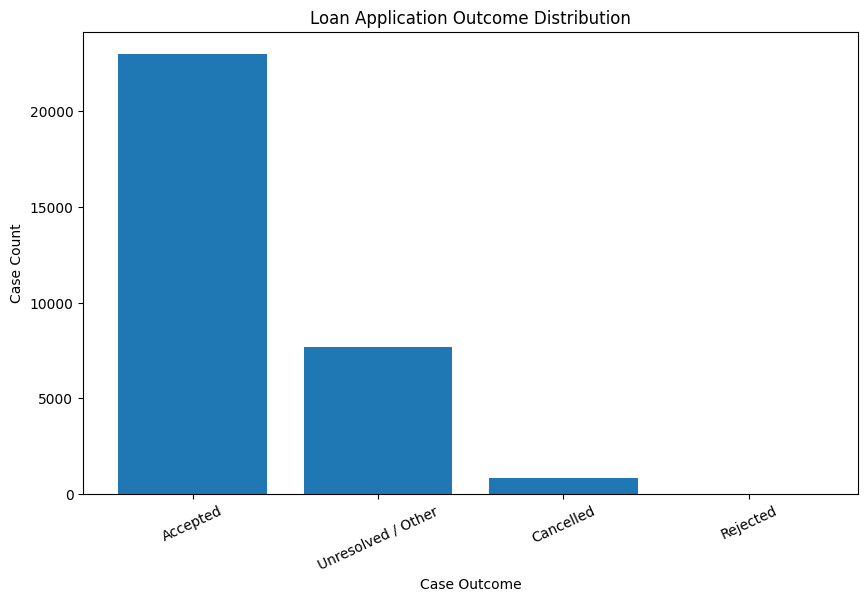

In [46]:
#case outcome dist
outcome_counts = (
    case_status_register["case_outcome"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    outcome_counts.index,
    outcome_counts.values
)

plt.title("Loan Application Outcome Distribution")
plt.xlabel("Case Outcome")
plt.ylabel("Case Count")

plt.xticks(rotation=25)

plt.show()

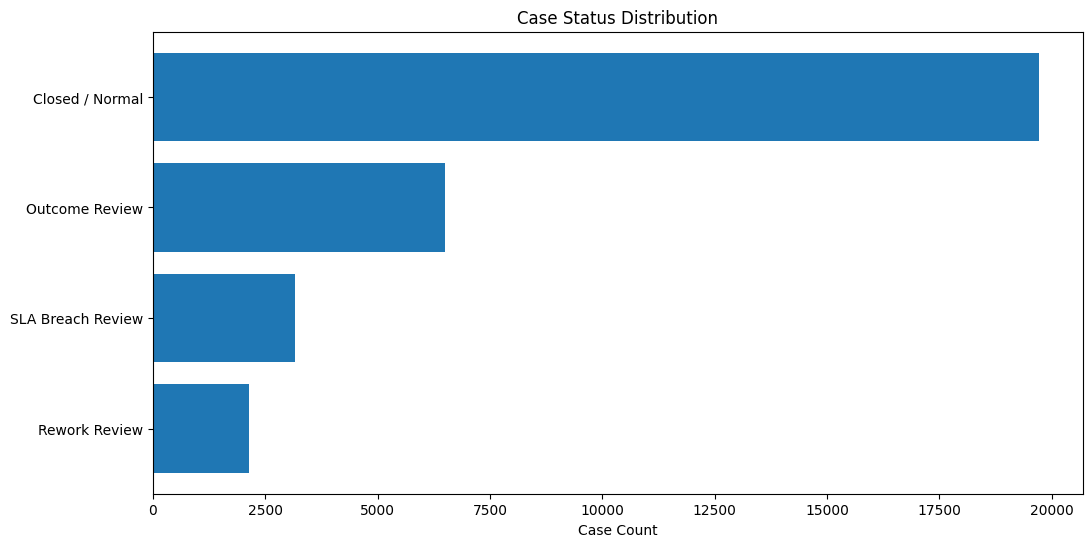

In [47]:
#case status dist
status_counts = (
    case_status_register["case_status"]
    .value_counts()
)

plt.figure(figsize=(12, 6))

plt.barh(
    status_counts.index,
    status_counts.values
)

plt.title("Case Status Distribution")
plt.xlabel("Case Count")

plt.gca().invert_yaxis()

plt.show()

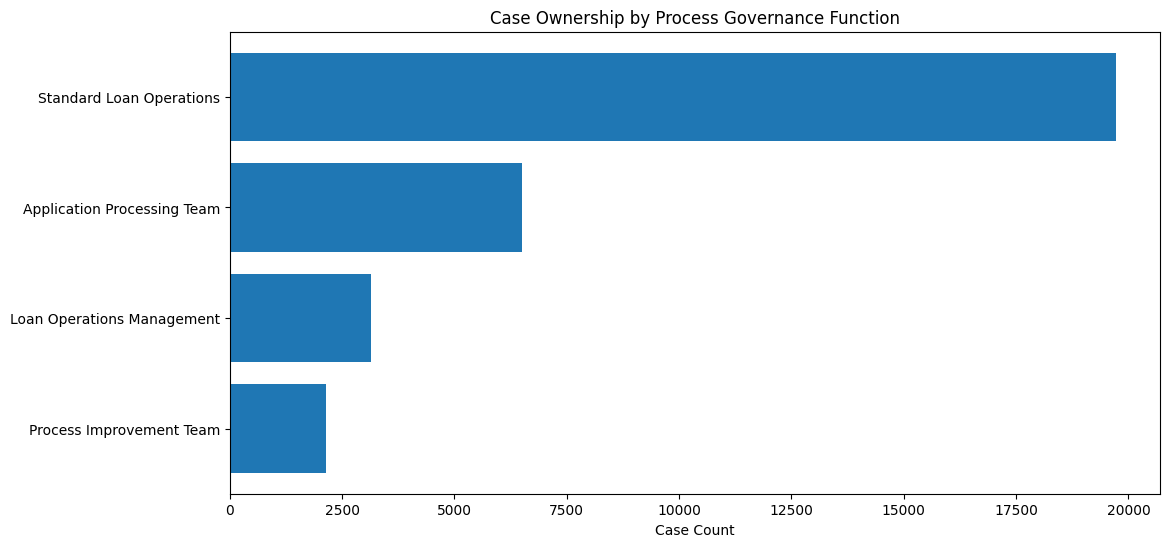

In [48]:
#case owner workload
owner_counts = (
    case_status_register["case_owner"]
    .value_counts()
)

plt.figure(figsize=(12, 6))

plt.barh(
    owner_counts.index,
    owner_counts.values
)

plt.title("Case Ownership by Process Governance Function")
plt.xlabel("Case Count")

plt.gca().invert_yaxis()

plt.show()

In [49]:
#risk level by outcome
risk_by_outcome = pd.crosstab(
    case_status_register["case_outcome"],
    case_status_register["process_risk_level"]
)

risk_by_outcome

process_risk_level,High,Low,Medium
case_outcome,,,
Accepted,117,20568,2329
Cancelled,20,624,181
Rejected,0,3,0
Unresolved / Other,24,6858,785


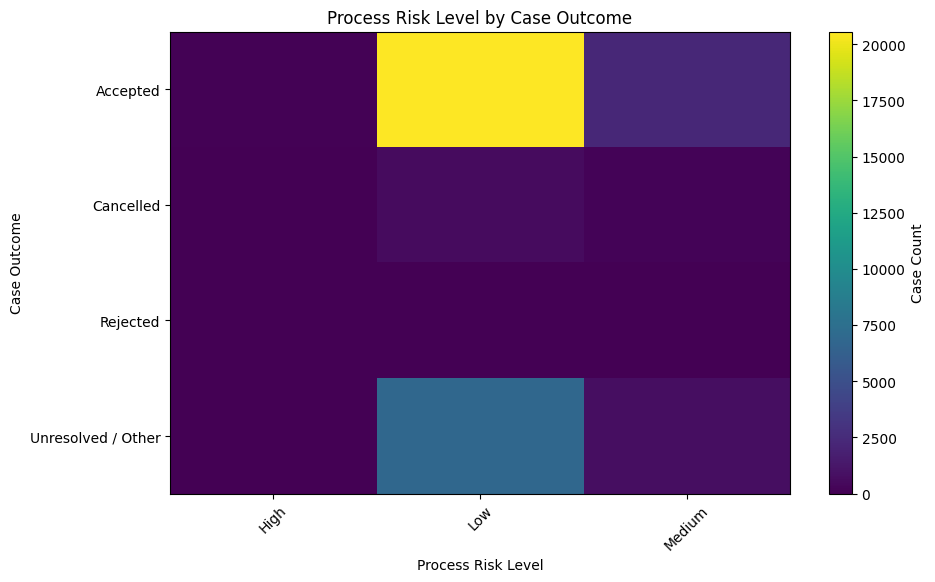

In [50]:
#heatmap
plt.figure(figsize=(10, 6))

plt.imshow(
    risk_by_outcome,
    aspect="auto"
)

plt.colorbar(label="Case Count")

plt.xticks(
    range(len(risk_by_outcome.columns)),
    risk_by_outcome.columns,
    rotation=45
)

plt.yticks(
    range(len(risk_by_outcome.index)),
    risk_by_outcome.index
)

plt.title("Process Risk Level by Case Outcome")
plt.xlabel("Process Risk Level")
plt.ylabel("Case Outcome")

plt.show()

In [52]:
##High risk case register

high_risk_case_register = case_status_register[
    case_status_register["process_risk_level"].isin([
        "High",
        "Critical"
    ])
].copy()

high_risk_case_register.head()

#save
high_risk_case_register.to_csv(
    "outputs/tables/high_risk_case_register.csv",
    index=False
)

print("High-risk case register saved successfully.")

High-risk case register saved successfully.


## Case Status and Outcome Register

A case status and outcome register was created to simulate enterprise process governance over the loan application workflow.

Each loan application case was assigned a final process outcome, operational status, governance owner, and recommended action based on its process characteristics. The classification logic evaluated final activity, accepted status, SLA breach indicators, excessive rework, missing credit score information, missing offered amount information, and process risk level.

The register supports operational oversight by identifying cases requiring additional review, including SLA breach cases, rework cases, unresolved outcomes, documentation exceptions, and high-risk cases.

This case-level register mirrors how operational risk, process governance, and business control teams monitor workflow exceptions, assign ownership, and prioritize remediation actions within a financial services environment.

The output supports:
- loan process governance
- SLA monitoring
- rework review
- documentation exception tracking
- case ownership assignment
- operational risk escalation
- audit readiness
- process improvement prioritization

---

In [53]:
##=====================##
##======DASHBOARD======##
##=====================##

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

Path("outputs/charts").mkdir(
    parents=True,
    exist_ok=True
)

#kpi calcs
total_cases = len(case_status_register)

avg_cycle_time = round(
    case_status_register["cycle_time_hours"].mean(),
    2
)

sla_breaches = int(
    case_status_register["sla_breach_flag"].sum()
)

rework_cases = int(
    case_status_register["excessive_rework_flag"].sum()
)

high_risk_cases = len(
    case_status_register[
        case_status_register["process_risk_level"] == "High"
    ]
)

critical_risk_cases = len(
    case_status_register[
        case_status_register["process_risk_level"] == "Critical"
    ]
)

unresolved_cases = len(
    case_status_register[
        case_status_register["case_outcome"] == "Unresolved / Other"
    ]
)

accepted_cases = len(
    case_status_register[
        case_status_register["case_outcome"] == "Accepted"
    ]
)

acceptance_rate = round(
    (accepted_cases / total_cases) * 100,
    2
) if total_cases > 0 else 0

print("Total Cases:", total_cases)
print("Average Cycle Time:", avg_cycle_time)
print("SLA Breaches:", sla_breaches)
print("Rework Cases:", rework_cases)
print("High Risk Cases:", high_risk_cases)
print("Critical Risk Cases:", critical_risk_cases)
print("Unresolved Cases:", unresolved_cases)
print("Acceptance Rate:", acceptance_rate)

Total Cases: 31509
Average Cycle Time: 525.59
SLA Breaches: 3151
Rework Cases: 3049
High Risk Cases: 161
Critical Risk Cases: 0
Unresolved Cases: 7667
Acceptance Rate: 73.04


In [54]:
#helper func
def format_number(value):
    value = float(value)

    if abs(value) >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    elif abs(value) >= 1_000:
        return f"{value / 1_000:.1f}K"
    else:
        return f"{value:,.0f}"


def create_kpi_card(ax, title, value, subtitle=None):
    ax.axis("off")

    rect = plt.Rectangle(
        (0, 0),
        1,
        1,
        fill=False,
        linewidth=1.5,
        transform=ax.transAxes
    )

    ax.add_patch(rect)

    ax.text(
        0.5,
        0.62,
        str(value),
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.30,
        title,
        ha="center",
        va="center",
        fontsize=10,
        wrap=True
    )

    if subtitle:
        ax.text(
            0.5,
            0.12,
            subtitle,
            ha="center",
            va="center",
            fontsize=8
        )

In [55]:
#chart data
risk_counts = (
    case_status_register["process_risk_level"]
    .value_counts()
)

status_counts = (
    case_status_register["case_status"]
    .value_counts()
    .sort_values(ascending=True)
)

outcome_counts = (
    case_status_register["case_outcome"]
    .value_counts()
)

owner_counts = (
    case_status_register["case_owner"]
    .value_counts()
    .sort_values(ascending=True)
)

failed_control_chart = (
    control_summary_df
    .sort_values("Failed", ascending=True)
    .copy()
)

failed_control_chart["Short Control"] = (
    failed_control_chart["Control"]
    .str.replace("CTRL-001 ", "", regex=False)
    .str.replace("CTRL-002 ", "", regex=False)
    .str.replace("CTRL-003 ", "", regex=False)
    .str.replace("CTRL-004 ", "", regex=False)
    .str.replace("CTRL-005 ", "", regex=False)
    .str.replace("CTRL-006 ", "", regex=False)
)

top_bottleneck_chart = top_bottlenecks.copy()

if "transition" not in top_bottleneck_chart.columns:
    top_bottleneck_chart["transition"] = (
        top_bottleneck_chart["activity"] 
        + " → " 
        + top_bottleneck_chart["next_activity"]
    )

top_bottleneck_chart = top_bottleneck_chart.head(8)

top_transition_chart = top_transitions.copy()

if "transition" not in top_transition_chart.columns:
    top_transition_chart["transition"] = (
        top_transition_chart["activity"] 
        + " → " 
        + top_transition_chart["next_activity"]
    )

top_transition_chart = top_transition_chart.head(8)

In [60]:
#LABEL CLEANING
def shorten_text(text, max_len=18):
    text = str(text).strip()
    return text if len(text) <= max_len else text[:max_len] + "..."

def clean_activity_name(name):
    name = str(name).strip()

    # remove prefixes
    for prefix in ["A_", "O_", "W_"]:
        if name.startswith(prefix):
            name = name.replace(prefix, "", 1)

    # aggressive short aliases
    alias_map = {
        "Create Application": "Create App",
        "Create Offer": "Create Offer",
        "Created": "Created",
        "Validate application": "Validate App",
        "Validating": "Validating",
        "Call after offers": "Call After Offer",
        "Call incomplete files": "Call Incomplete",
        "Complete application": "Complete App",
        "Handle leads": "Handle Leads",
        "Personal Loan collection": "Loan Collection",
        "Sent (mail and online)": "Sent Mail+Online",
        "Sent (online only)": "Sent Online",
        "Cancelled": "Cancelled",
        "Accepted": "Accepted",
        "Refused": "Refused",
        "Shortened completion": "Short Completion"
    }

    for old, new in alias_map.items():
        if old in name:
            name = name.replace(old, new)

    return shorten_text(name, max_len=16)


def clean_transition_label(label):
    label = str(label)

    if "→" in label:
        left, right = label.split("→", 1)
        left = clean_activity_name(left.strip())
        right = clean_activity_name(right.strip())
        return f"{left} → {right}"

    return shorten_text(label, max_len=24)


def clean_owner_label(label):
    label = str(label).strip()

    alias_map = {
        "Standard Loan Operations": "Std Loan Ops",
        "Application Processing Team": "App Processing",
        "Loan Operations Management": "Loan Ops Mgmt",
        "Process Improvement Team": "Proc Improve",
        "Operational Risk Team": "Op Risk",
        "Loan Quality Assurance": "Loan QA"
    }

    for old, new in alias_map.items():
        label = label.replace(old, new)

    return shorten_text(label, max_len=18)


def clean_status_label(label):
    label = str(label).strip()

    alias_map = {
        "Closed / Normal": "Closed",
        "Outcome Review": "Outcome Review",
        "SLA Breach Review": "SLA Review",
        "Rework Review": "Rework Review",
        "Documentation Review": "Doc Review",
        "Offer Data Review": "Offer Review",
        "Escalated": "Escalated"
    }

    for old, new in alias_map.items():
        label = label.replace(old, new)

    return shorten_text(label, max_len=16)


def clean_outcome_label(label):
    label = str(label).strip()

    alias_map = {
        "Unresolved / Other": "Unresolved",
        "Cancelled": "Cancelled",
        "Accepted": "Accepted",
        "Rejected": "Rejected",
        "Withdrawn": "Withdrawn"
    }

    for old, new in alias_map.items():
        label = label.replace(old, new)

    return shorten_text(label, max_len=14)


def format_number(value):
    value = float(value)

    if abs(value) >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    elif abs(value) >= 1_000:
        return f"{value / 1_000:.1f}K"
    else:
        return f"{value:,.0f}"

In [61]:
#rebuild chart data with new labels
risk_counts = (
    case_status_register["process_risk_level"]
    .value_counts()
)

outcome_counts = (
    case_status_register["case_outcome"]
    .value_counts()
)
outcome_counts.index = [clean_outcome_label(x) for x in outcome_counts.index]

status_counts = (
    case_status_register["case_status"]
    .value_counts()
    .sort_values(ascending=True)
)
status_counts.index = [clean_status_label(x) for x in status_counts.index]

owner_counts = (
    case_status_register["case_owner"]
    .value_counts()
    .sort_values(ascending=True)
)
owner_counts.index = [clean_owner_label(x) for x in owner_counts.index]

failed_control_chart = (
    control_summary_df
    .sort_values("Failed", ascending=True)
    .copy()
)

failed_control_chart["Short Control"] = (
    failed_control_chart["Control"]
    .str.replace("CTRL-001 ", "", regex=False)
    .str.replace("CTRL-002 ", "", regex=False)
    .str.replace("CTRL-003 ", "", regex=False)
    .str.replace("CTRL-004 ", "", regex=False)
    .str.replace("CTRL-005 ", "", regex=False)
    .str.replace("CTRL-006 ", "", regex=False)
    .replace({
        "Cycle Time Within SLA": "Cycle Time SLA",
        "Rework Within Threshold": "Rework Threshold",
        "Offered Amount Present": "Offer Amount",
        "Credit Score Present": "Credit Score",
        "Requested Amount Present": "Req Amount",
        "Case Start and End Present": "Case Start/End"
    })
)

top_bottleneck_chart = top_bottlenecks.copy()

if "transition" not in top_bottleneck_chart.columns:
    top_bottleneck_chart["transition"] = (
        top_bottleneck_chart["activity"] +
        " → " +
        top_bottleneck_chart["next_activity"]
    )

top_bottleneck_chart = top_bottleneck_chart.head(6)
top_bottleneck_chart["short_transition"] = (
    top_bottleneck_chart["transition"]
    .apply(clean_transition_label)
)

top_transition_chart = top_transitions.copy()

if "transition" not in top_transition_chart.columns:
    top_transition_chart["transition"] = (
        top_transition_chart["activity"] +
        " → " +
        top_transition_chart["next_activity"]
    )

top_transition_chart = top_transition_chart.head(6)
top_transition_chart["short_transition"] = (
    top_transition_chart["transition"]
    .apply(clean_transition_label)
)

top_bottleneck_chart = top_bottleneck_chart.head(5)
top_transition_chart = top_transition_chart.head(5)

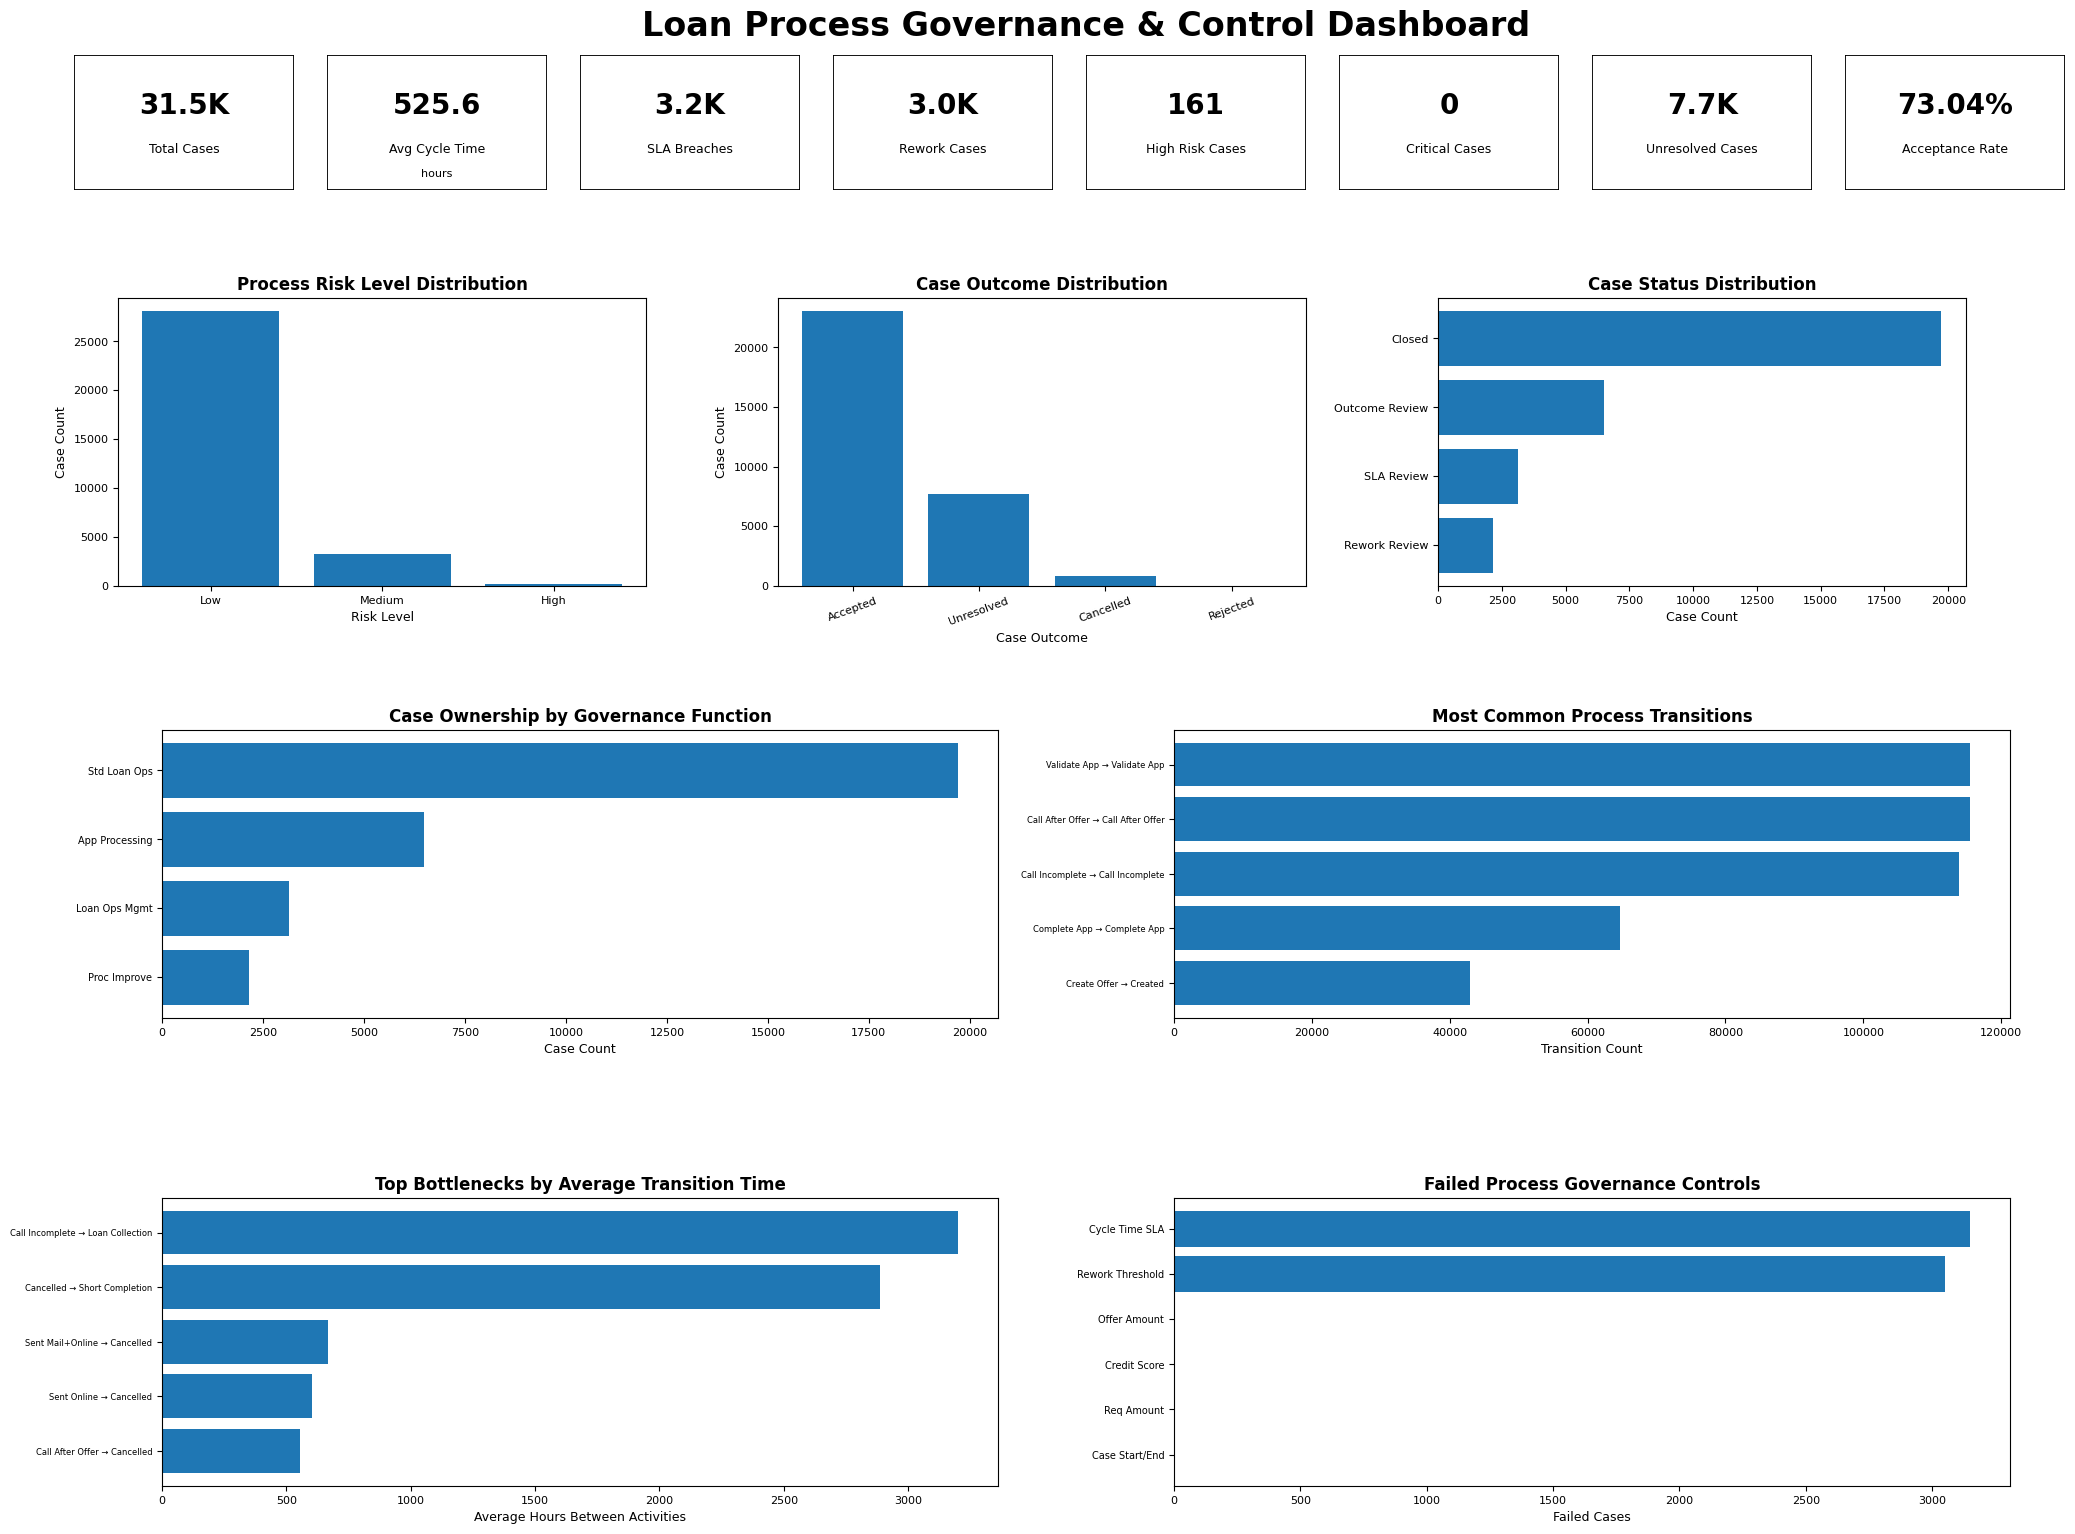

In [62]:
#dash
fig = plt.figure(figsize=(22, 18))

fig.suptitle(
    "Loan Process Governance & Control Dashboard",
    fontsize=24,
    fontweight="bold",
    y=0.98
)

# KPI helper
def create_kpi_card(ax, title, value, subtitle=None):
    ax.axis("off")

    rect = plt.Rectangle(
        (0, 0),
        1,
        1,
        fill=False,
        linewidth=1.3,
        transform=ax.transAxes
    )
    ax.add_patch(rect)

    ax.text(
        0.5, 0.62, str(value),
        ha="center", va="center",
        fontsize=20, fontweight="bold"
    )

    ax.text(
        0.5, 0.30, title,
        ha="center", va="center",
        fontsize=9, wrap=True
    )

    if subtitle:
        ax.text(
            0.5, 0.12, subtitle,
            ha="center", va="center",
            fontsize=8
        )

# KPI cards
kpi_positions = [
    [0.04, 0.88, 0.10, 0.075],
    [0.155, 0.88, 0.10, 0.075],
    [0.27, 0.88, 0.10, 0.075],
    [0.385, 0.88, 0.10, 0.075],
    [0.50, 0.88, 0.10, 0.075],
    [0.615, 0.88, 0.10, 0.075],
    [0.73, 0.88, 0.10, 0.075],
    [0.845, 0.88, 0.10, 0.075]
]

kpi_values = [
    ("Total Cases", format_number(total_cases), None),
    ("Avg Cycle Time", f"{avg_cycle_time:,.1f}", "hours"),
    ("SLA Breaches", format_number(sla_breaches), None),
    ("Rework Cases", format_number(rework_cases), None),
    ("High Risk Cases", format_number(high_risk_cases), None),
    ("Critical Cases", format_number(critical_risk_cases), None),
    ("Unresolved Cases", format_number(unresolved_cases), None),
    ("Acceptance Rate", f"{acceptance_rate}%", None)
]

for pos, item in zip(kpi_positions, kpi_values):
    ax = fig.add_axes(pos)
    create_kpi_card(ax, item[0], item[1], item[2])

# Row 1
ax1 = fig.add_axes([0.06, 0.66, 0.24, 0.16])
ax1.bar(risk_counts.index, risk_counts.values)
ax1.set_title("Process Risk Level Distribution", fontsize=12, fontweight="bold")
ax1.set_xlabel("Risk Level", fontsize=9)
ax1.set_ylabel("Case Count", fontsize=9)
ax1.tick_params(labelsize=8)

ax2 = fig.add_axes([0.36, 0.66, 0.24, 0.16])
ax2.bar(outcome_counts.index, outcome_counts.values)
ax2.set_title("Case Outcome Distribution", fontsize=12, fontweight="bold")
ax2.set_xlabel("Case Outcome", fontsize=9)
ax2.set_ylabel("Case Count", fontsize=9)
ax2.tick_params(axis="x", rotation=20, labelsize=8)
ax2.tick_params(axis="y", labelsize=8)

ax3 = fig.add_axes([0.66, 0.66, 0.24, 0.16])
ax3.barh(status_counts.index, status_counts.values)
ax3.set_title("Case Status Distribution", fontsize=12, fontweight="bold")
ax3.set_xlabel("Case Count", fontsize=9)
ax3.tick_params(axis="y", labelsize=8)
ax3.tick_params(axis="x", labelsize=8)

# Row 2
ax4 = fig.add_axes([0.08, 0.42, 0.38, 0.16])
ax4.barh(owner_counts.index, owner_counts.values)
ax4.set_title("Case Ownership by Governance Function", fontsize=12, fontweight="bold")
ax4.set_xlabel("Case Count", fontsize=9)
ax4.tick_params(axis="y", labelsize=7)
ax4.tick_params(axis="x", labelsize=8)

ax5 = fig.add_axes([0.54, 0.42, 0.38, 0.16])
ax5.barh(top_transition_chart["short_transition"], top_transition_chart["transition_count"])
ax5.set_title("Most Common Process Transitions", fontsize=12, fontweight="bold")
ax5.set_xlabel("Transition Count", fontsize=9)
ax5.invert_yaxis()
ax5.tick_params(axis="y", labelsize=6)
ax5.tick_params(axis="x", labelsize=8)

# Row 3
ax6 = fig.add_axes([0.08, 0.16, 0.38, 0.16])
ax6.barh(top_bottleneck_chart["short_transition"], top_bottleneck_chart["mean"])
ax6.set_title("Top Bottlenecks by Average Transition Time", fontsize=12, fontweight="bold")
ax6.set_xlabel("Average Hours Between Activities", fontsize=9)
ax6.invert_yaxis()
ax6.tick_params(axis="y", labelsize=6)
ax6.tick_params(axis="x", labelsize=8)

ax7 = fig.add_axes([0.54, 0.16, 0.38, 0.16])
ax7.barh(failed_control_chart["Short Control"], failed_control_chart["Failed"])
ax7.set_title("Failed Process Governance Controls", fontsize=12, fontweight="bold")
ax7.set_xlabel("Failed Cases", fontsize=9)
ax7.tick_params(axis="y", labelsize=7)
ax7.tick_params(axis="x", labelsize=8)

plt.savefig(
    "outputs/charts/loan_process_governance_dashboard_clean2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Executive Process Governance Dashboard

The Loan Process Governance & Control Dashboard provides an executive-level view of loan application workflow performance, operational risk exposure, process bottlenecks, and control effectiveness.

The dashboard consolidates key process governance indicators, including total loan cases, average cycle time, SLA breaches, excessive rework cases, high-risk cases, critical-risk cases, unresolved cases, and application acceptance rate.

The process risk distribution summarizes the number of loan applications classified by operational risk level. The transition matrix visualizes how cases move between key process activities, supporting workflow transparency and process mapping.

The case outcome and case status views show how loan applications are resolved and which cases require additional governance review. Case ownership analysis identifies which process governance functions are responsible for reviewing exceptions, SLA breaches, rework cases, and unresolved outcomes.

The bottleneck analysis highlights the activity transitions with the longest average delay, helping identify workflow inefficiencies and opportunities for process improvement.

The failed control chart summarizes process governance control failures, including SLA breaches, missing documentation fields, and excessive rework indicators.

Overall, this dashboard supports business process monitoring, operational risk oversight, control testing, SLA management, process improvement, and audit readiness.

---

In [63]:
#save outputs

from pathlib import Path

Path("outputs/tables").mkdir(parents=True, exist_ok=True)

case_summary.to_csv(
    "outputs/tables/case_level_process_summary.csv",
    index=False
)

case_status_register.to_csv(
    "outputs/tables/case_status_outcome_register.csv",
    index=False
)

high_risk_case_register.to_csv(
    "outputs/tables/high_risk_case_register.csv",
    index=False
)

control_summary_df.to_csv(
    "outputs/tables/process_control_testing_summary.csv",
    index=False
)

transition_counts.to_csv(
    "outputs/tables/process_transition_counts.csv",
    index=False
)

transition_matrix.to_csv(
    "outputs/tables/process_transition_matrix.csv"
)

transition_times.to_csv(
    "outputs/tables/process_bottleneck_analysis.csv",
    index=False
)

print("All Project 4 tables saved successfully.")

All Project 4 tables saved successfully.


# Final Project Summary

This project analyzed a loan application event-log dataset from a business process governance and operational risk perspective.

The objective was to evaluate how loan applications move through the process, identify bottlenecks, measure cycle time, detect rework, monitor SLA breaches, test process controls, and assign case-level governance statuses.

The project transformed raw event-log data into an enterprise-style process governance framework by creating:

- case-level process summaries
- cycle time calculations
- process bottleneck analysis
- transition matrices
- process flow mapping
- SLA breach indicators
- excessive rework indicators
- automated control testing summaries
- case outcome classifications
- case ownership assignments
- high-risk case registers
- executive process governance dashboards

The final dashboard provides leadership with visibility into process performance, unresolved cases, SLA breaches, rework exposure, control failures, process ownership, and bottleneck transitions.

This project demonstrates how process mining concepts can be used to support operational risk management, business process improvement, audit readiness, and governance reporting.

---

# Key Findings

## Finding 1 — SLA Breach Exposure

A portion of loan application cases exceeded the established cycle time SLA threshold. These cases may indicate workflow delays, processing inefficiencies, staffing constraints, or handoff issues between process activities.

## Finding 2 — Rework Concentration

Several cases showed excessive event counts, indicating potential rework or repeated activity. Rework may result from incomplete documentation, repeated customer contact, duplicate validations, or process design inefficiencies.

## Finding 3 — Bottleneck Transitions

The bottleneck analysis identified specific activity-to-activity transitions with high average delay times. These transitions represent opportunities for process improvement, automation, workload balancing, or revised escalation rules.

## Finding 4 — Unresolved Outcomes

A meaningful number of cases were classified as unresolved or requiring outcome review. These cases may require final status validation to improve reporting accuracy and process transparency.

## Finding 5 — Control Testing Results

Automated process controls were tested across the case population. Failed controls were primarily associated with cycle time SLA breaches and excessive rework thresholds, indicating areas where process governance monitoring should be strengthened.

---

# Recommendations

## Process Governance Improvements

- Implement recurring cycle time monitoring by process stage.
- Create automated SLA alerts for cases exceeding expected processing time.
- Maintain a case-level process governance register.
- Review unresolved cases to confirm final application outcomes.

## Process Improvement Recommendations

- Investigate the highest-delay activity transitions.
- Analyze repeated activity patterns to identify root causes of rework.
- Standardize handoff procedures between major process steps.
- Evaluate whether automation could reduce manual processing delays.

## Control and Audit Readiness Recommendations

- Maintain automated control testing summaries for SLA, rework, and documentation controls.
- Create periodic process governance dashboards for management review.
- Assign case ownership for SLA breaches, rework cases, and unresolved outcomes.
- Preserve transition matrices and bottleneck reports as audit-supporting evidence.

## Operational Risk Recommendations

- Escalate high-risk cases to operational risk or process governance teams.
- Monitor high-value applications with elevated process risk scores.
- Use case status registers to prioritize remediation and management review.

---